# 分类算法矩阵

## 分类准确度
0-1之间，越大越好

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
# 导入数据
filename = 'pima_data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
# 将数据分为输入数据和输出结果
array = data.values
X = array[:, 0:8]
Y = array[:, 8]
num_folds = 10
seed = 7

kfold = KFold(n_splits=num_folds, shuffle = True, random_state=seed)
model = LogisticRegression()
result = cross_val_score(model, X, Y, cv = kfold)
print("算法评估结果准确度：%.3f (%.3f)" % (result.mean(), result.std())) # 提供的代码中%多写了，这里需要做修正

算法评估结果准确度：0.773 (0.044)


## 对数损失函数
直接计算的结果是[0,+∞),
取反则为(-∞,0
]
越接近0越好

In [11]:
import warnings
warnings.filterwarnings('ignore')

from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
# 导入数据
filename = 'pima_data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
# 将数据分为输入数据和输出结果
array = data.values
X = array[:, 0:8]
Y = array[:, 8]
num_folds = 10
seed = 7
kfold = KFold(n_splits=num_folds, shuffle = True, random_state = seed)
model = LogisticRegression()
scoring = 'neg_log_loss'

result = cross_val_score(model, X, Y, cv = kfold, scoring = scoring)
print('Logloss %.3f (%.3f)' % (result.mean(), result.std()))

Logloss -0.495 (0.060)


## AUC图
ROC图下方的面积；取值在0-1之间，越大越好

In [12]:
import warnings
warnings.filterwarnings('ignore')

from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
# 导入数据
filename = 'pima_data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
# 将数据分为输入数据和输出结果
array = data.values
X = array[:, 0:8]
Y = array[:, 8]
num_folds = 10
seed = 7

kfold = KFold(n_splits=num_folds, shuffle = True, random_state = seed)
model = LogisticRegression()
scoring = 'roc_auc'
result = cross_val_score(model, X, Y, cv = kfold, scoring = scoring)

print('AUC %.3f (%.3f)' % (result.mean(), result.std()))

AUC 0.824 (0.051)


## AUC图的补充

AUC: 0.818


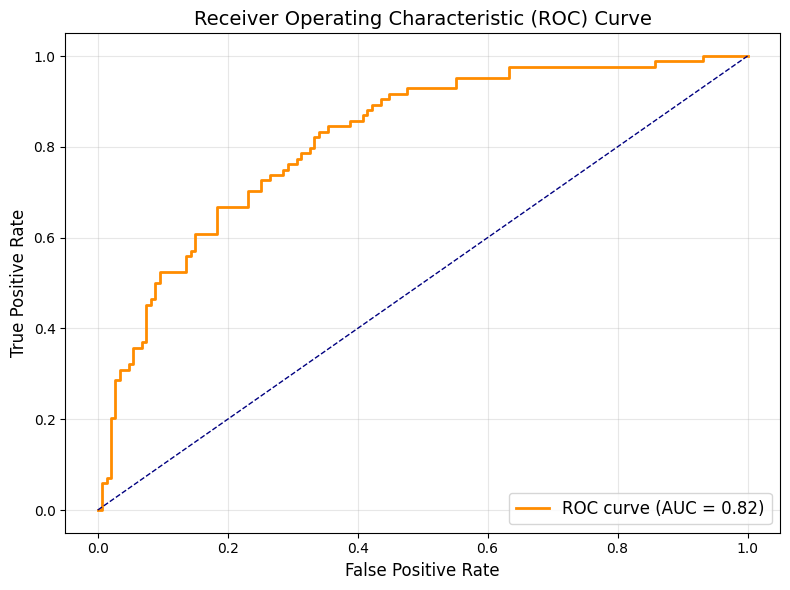

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# 导入数据
filename = 'pima_data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)

# 将数据分为输入数据和输出结果
array = data.values
X = array[:, 0:8]
Y = array[:, 8].astype('int')  # 确保目标变量为整数类型
seed = 7

# 划分数据集：70%训练，30%验证
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.3, random_state=seed
)

# 训练逻辑回归模型
model = LogisticRegression(random_state=seed)
model.fit(X_train, Y_train)

# 在验证集上预测概率
probas = model.predict_proba(X_val)[:, 1]  # 获取正类的概率

# 计算ROC曲线和AUC值
fpr, tpr, thresholds = roc_curve(Y_val, probas)
roc_auc = auc(fpr, tpr)

# 打印AUC结果
print('AUC: %.3f' % roc_auc)

# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')  # 随机猜测线

# 设置图形属性
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

# 显示图形
plt.tight_layout()
plt.savefig("AUC.png")
plt.show()

## 混淆矩阵
对角线上的是分类正确的情况，其他的根据实际情况做判断；是分类正确率的详细说明

In [4]:
import warnings
warnings.filterwarnings('ignore')

from pandas import read_csv
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
# 导入数据
filename = 'pima_data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names = names)
# 将数据分为输入数据和输出结果
array = data.values
X = array[:, 0:8]
Y = array[:, 8]
test_size = 0.33 # 注意这里只有1-0.33的数据用于训练了
seed = 4

X_train, X_test, Y_traing, Y_test = train_test_split(X, Y, test_size = test_size, shuffle = True, random_state = seed)
model = LogisticRegression()
model.fit(X_train, Y_traing)
predicted = model.predict(X_test)

matrix = confusion_matrix(Y_test, predicted) # 0.33的数据用于验证结果，768*0.33
classes = ['0', '1']
dataframe = pd.DataFrame(data = matrix, index = classes, columns = classes)
print(dataframe)

     0   1
0  150  21
1   28  55


## 分类报告

In [14]:
import warnings
warnings.filterwarnings('ignore')

from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
# 导入数据
filename = 'pima_data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
# 将数据分为输入数据和输出结果
array = data.values
X = array[:, 0:8]
Y = array[:, 8]
test_size = 0.33
seed = 4

X_train, X_test, Y_traing, Y_test = train_test_split(X, Y, test_size=test_size, shuffle = True, random_state=seed)
model = LogisticRegression()
model.fit(X_train, Y_traing)

predicted = model.predict(X_test)
report = classification_report(Y_test, predicted)
print(report)

              precision    recall  f1-score   support

         0.0       0.84      0.88      0.86       171
         1.0       0.72      0.66      0.69        83

    accuracy                           0.81       254
   macro avg       0.78      0.77      0.78       254
weighted avg       0.80      0.81      0.80       254



# 回归算法矩阵

## 平均绝对误差MAE
注意，打印的均值和标准差是交叉验证的10组MAE的均值和标准差，不是Y与Y_hat的差值的    
MAE计算结果取值区间是[0,+∞),
取反则为(-∞,0
]
越接近0越好

In [16]:
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
# 导入数据
filename = 'housing.csv'
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PRTATIO', 'B', 'LSTAT', 'MEDV']
data = read_csv(filename, names = names, delim_whitespace = True)
# 将数据分为输入数据和输出结果
array = data.values
X = array[:, 0:13]
Y = array[:, 13]
n_splits = 10
seed = 7

kfold = KFold(n_splits = n_splits, shuffle = True, random_state = seed)
model = LinearRegression()
scoring = 'neg_mean_absolute_error'
result = cross_val_score(model, X, Y, cv = kfold, scoring = scoring)
print('MAE: %.3f (%.3f)' % (result.mean(), result.std()))

MAE: -3.387 (0.667)


## 均方误差MSE
MSE计算结果取值区间是[0,+∞),
取反则为(-∞,0
]
越接近0越好

In [18]:
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
# 导入数据
filename = 'housing.csv'
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PRTATIO', 'B', 'LSTAT', 'MEDV']
data = read_csv(filename, names=names, delim_whitespace=True)
# 将数据分为输入数据和输出结果
array = data.values
X = array[:, 0:13]
Y = array[:, 13]
n_splits = 10
seed = 7

kfold = KFold(n_splits = n_splits, shuffle = True, random_state = seed)
model = LinearRegression()
scoring = 'neg_mean_squared_error'
result = cross_val_score(model, X, Y, cv = kfold, scoring = scoring)
print('MSE: %.3f (%.3f)' % (result.mean(), result.std()))

MSE: -23.747 (11.143)


## 决定系数

In [19]:
from pandas import read_csv
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
# 导入数据
filename = 'housing.csv'
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PRTATIO', 'B', 'LSTAT', 'MEDV']
data = read_csv(filename, names=names, delim_whitespace=True)
# 将数据分为输入数据和输出结果
array = data.values
X = array[:, 0:13]
Y = array[:, 13]
n_splits = 10
seed = 7

kfold = KFold(n_splits = n_splits, shuffle = True, random_state = seed)
model = LinearRegression()
scoring = 'r2'

result = cross_val_score(model, X, Y, cv = kfold, scoring = scoring)
print('R2: %.3f (%.3f)' % (result.mean(), result.std()))

R2: 0.718 (0.099)
